# Hypothesis tests: baseline + extended robustness checks

This notebook formalizes the project's customer-experience hypotheses with **pre-specified significance tests**.

- **H1–H4** (descriptive baseline) live in `sql/05_analysis.sql` and `notebooks/01_visualizations.ipynb`.
- **H5–H12** add robustness / controls (region, freight ratio, complexity, on-time category risk, seller deconfounding, retention timing).
- Data are loaded at **order level** from raw CSVs using the same logic as `mart_order_fact` (see `scripts/export_extended_analysis.py`). Optional MySQL loading is supported via environment variables.

**Rules of interpretation**

- α = 0.05
- Primary outcomes are binary (`is_low_review`, repeat purchase) → proportion / χ² family
- Ordered delay / freight buckets → omnibus χ² **plus** Cochran–Armitage trend
- Stratified associations → Mantel–Haenszel
- Multiple category comparisons → Benjamini–Hochberg FDR
- Statistical significance ≠ causation
- **H9** is restricted to **on-time** deliveries to hold logistics roughly constant
- **H10/H11** may show small effects — report magnitude, do not overclaim retention impact


### Setup

In [1]:
from pathlib import Path
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", palette="deep")

_cwd = Path.cwd()
if (_cwd / "data" / "raw").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data" / "raw").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise FileNotFoundError("Could not find data/raw/. Run from project root or notebooks/.")

sys.path.insert(0, str(PROJECT_ROOT))
from scripts.export_extended_analysis import build_mart_order_fact, delivered_reviewed, RAW_DIR
from scripts.run_hypothesis_tests import (
    cramers_v,
    cochran_armitage,
    odds_ratio_2x2,
    cliff_delta,
    delay_bucket,
    ALPHA,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

USE_MYSQL = bool(os.getenv("MYSQL_USER"))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Data source:", "MySQL" if USE_MYSQL else "raw CSVs (mart-equivalent)")


PROJECT_ROOT: /home/mateusz/VScode/marketplace-customer-experience-analysis
Data source: raw CSVs (mart-equivalent)


### Load order-level analysis frame

In [2]:
if USE_MYSQL:
    from sqlalchemy import create_engine

    user = os.environ["MYSQL_USER"]
    password = os.environ.get("MYSQL_PASSWORD", "")
    host = os.environ.get("MYSQL_HOST", "localhost")
    database = os.environ.get("MYSQL_DATABASE", "olist_analytics")
    engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")
    mart = pd.read_sql("SELECT * FROM mart_order_fact", engine)
else:
    mart = build_mart_order_fact()

df = delivered_reviewed(mart)
df_delay = df[df["delivery_delay_days"].notna() & df["is_late_delivery"].notna()].copy()
df_delay["delay_bucket"] = df_delay["delivery_delay_days"].map(delay_bucket)
bucket_order = ["On time or early", "1-3 days late", "4-7 days late", "8+ days late"]

print(f"Delivered + reviewed orders: {len(df):,}")
print(f"With delivery delay: {len(df_delay):,}")
df[["order_id", "customer_state", "review_score", "is_low_review", "is_late_delivery", "item_count"]].head()


Delivered + reviewed orders: 95,832
With delivery delay: 95,824


,order_id,customer_state,review_score,is_low_review,is_late_delivery,item_count
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0,0.0,0.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,BA,4.0,0.0,0.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0,0.0,0.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,5.0,0.0,0.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,5.0,0.0,0.0,1.0


### H1 — Delivery delay vs low review (baseline confirmation)

**H0:** Low-review rate is independent of delay bucket.
**H1alt:** Low-review rate differs by delay bucket (and increases with lateness).

**Test choice:** χ² + **Cochran–Armitage** (ordered trend). Binary outcome × ordered exposure.


is_low_review,0.0,1.0,low_review_rate_pct
delay_bucket,,,
On time or early,81186,8257,9.231578
1-3 days late,1256,596,32.181425
4-7 days late,567,1181,67.562929
8+ days late,579,2202,79.180151


Chi-square=17354.6, p=0, Cramer's V=0.426
Cochran-Armitage Z=131.08, p=0


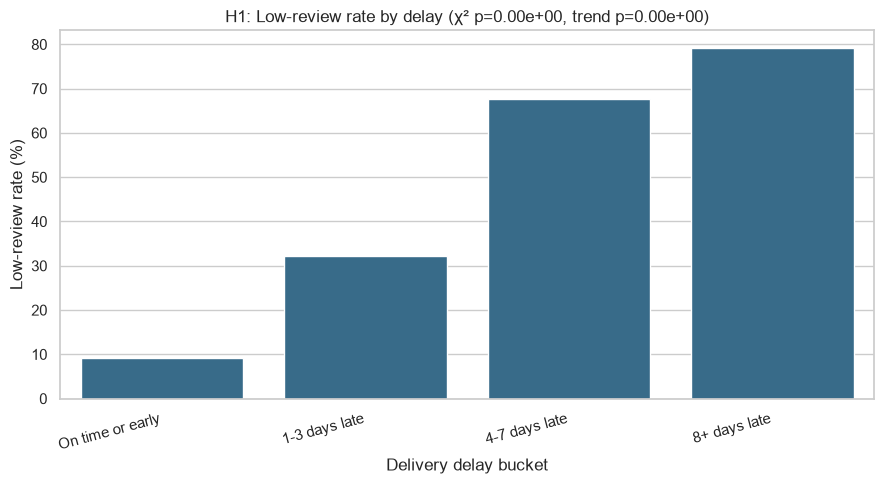

In [3]:
ct1 = pd.crosstab(df_delay["delay_bucket"], df_delay["is_low_review"]).reindex(bucket_order)
chi2, p_chi, _, _ = stats.chi2_contingency(ct1.values)
table_h1 = np.array([ct1[1.0].values, ct1[0.0].values], dtype=float)
z_ca, p_ca = cochran_armitage(table_h1, np.arange(len(bucket_order)))
v1 = cramers_v(ct1.values)

display(ct1.assign(low_review_rate_pct=lambda t: 100 * t[1.0] / t.sum(axis=1)))
print(f"Chi-square={chi2:.1f}, p={p_chi:.3g}, Cramer's V={v1:.3f}")
print(f"Cochran-Armitage Z={z_ca:.2f}, p={p_ca:.3g}")

rate_by_bucket = df_delay.groupby("delay_bucket")["is_low_review"].mean().reindex(bucket_order) * 100
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=rate_by_bucket.index, y=rate_by_bucket.values, ax=ax, color="#2a6f97")
ax.set_ylabel("Low-review rate (%)")
ax.set_xlabel("Delivery delay bucket")
ax.set_title(f"H1: Low-review rate by delay (χ² p={p_chi:.2e}, trend p={p_ca:.2e})")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "h1_delay_significance.png", dpi=150)
plt.show()


### H5 / H5b — Region

**H5:** χ² independence of state vs low review (states with ≥200 orders).
**H5b:** Mantel–Haenszel for late vs low review stratified by state.


In [4]:
state_counts = df_delay["customer_state"].value_counts()
states_ok = state_counts[state_counts >= 200].index
df_state = df_delay[df_delay["customer_state"].isin(states_ok)]

ct5 = pd.crosstab(df_state["customer_state"], df_state["is_low_review"])
chi2_5, p5, _, _ = stats.chi2_contingency(ct5.values)
v5 = cramers_v(ct5.values)
print(f"H5 Chi-square={chi2_5:.1f}, p={p5:.3g}, Cramer's V={v5:.3f}")

tables = []
for _, g in df_state.groupby("customer_state"):
    ct = pd.crosstab(g["is_late_delivery"], g["is_low_review"])
    ct = ct.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)
    if ct.values.sum() >= 20:
        tables.append(ct.values)

st = StratifiedTable(tables)
mh = st.test_null_odds()
print(f"H5b Mantel-Haenszel stat={float(mh.statistic):.1f}, p={float(mh.pvalue):.3g}")
print(f"Common OR (late vs on-time for low review)={float(st.oddsratio_pooled):.2f}")


H5 Chi-square=710.2, p=5.54e-136, Cramer's V=0.086
H5b Mantel-Haenszel stat=11479.7, p=0
Common OR (late vs on-time for low review)=11.28


### H6/H7 — Freight-ratio terciles (one simple axis)

**H0:** Low-review rate independent of freight-ratio tercile.
**Test:** χ² + Cochran–Armitage. No parallel GMV/quartile variants.


In [5]:
freight = df[
    df["item_revenue"].notna() & (df["item_revenue"] > 0) & df["freight_revenue"].notna()
].copy()
freight["freight_ratio"] = freight["freight_revenue"] / freight["item_revenue"]
freight["tercile"] = pd.qcut(
    freight["freight_ratio"].rank(method="first"), 3, labels=[1, 2, 3]
).astype(int)

ct6 = pd.crosstab(freight["tercile"], freight["is_low_review"])
chi2_6, p6, _, _ = stats.chi2_contingency(ct6.values)
z6, p_ca6 = cochran_armitage(
    np.array([ct6[1.0].values, ct6[0.0].values], dtype=float),
    np.array([1, 2, 3]),
)
v6 = cramers_v(ct6.values)

rate = freight.groupby("tercile")["is_low_review"].mean() * 100
display(pd.DataFrame({
    "tercile": [1, 2, 3],
    "bucket": ["Low freight ratio", "Mid freight ratio", "High freight ratio"],
    "low_review_rate_pct": rate.reindex([1, 2, 3]).values.round(2),
}))
print(f"Chi-square={chi2_6:.2f}, p={p6:.3g}, V={v6:.3f}; trend Z={z6:.2f}, p={p_ca6:.3g}")
print("Interpretation: detectable association, but effect size is tiny vs delivery delay.")


,tercile,bucket,low_review_rate_pct
0,1,Low freight ratio,12.26
1,2,Mid freight ratio,12.62
2,3,High freight ratio,13.43


Chi-square=20.84, p=2.99e-05, V=0.015; trend Z=4.46, p=8.3e-06
Interpretation: detectable association, but effect size is tiny vs delivery delay.


### H8 — Order complexity (multi-item)

**Tests:** χ² (2×2) + Mantel–Haenszel stratified by late delivery.


In [6]:
comp = df[df["item_count"].notna()].copy()
comp["multi_item"] = (comp["item_count"] > 1).astype(int)
ct8 = pd.crosstab(comp["multi_item"], comp["is_low_review"])
chi2_8, p8, _, _ = stats.chi2_contingency(ct8.values)
ct8_or = ct8.reindex(index=[1, 0], columns=[1.0, 0.0])
or8 = odds_ratio_2x2(ct8_or.values)

mh_tables = []
for _, g in comp[comp["is_late_delivery"].notna()].groupby("is_late_delivery"):
    ct = pd.crosstab(g["multi_item"], g["is_low_review"])
    ct = ct.reindex(index=[0, 1], columns=[0.0, 1.0], fill_value=0)
    mh_tables.append(ct.values)
st8 = StratifiedTable(mh_tables)
mh8 = st8.test_null_odds()

print(ct8)
print(f"Chi-square={chi2_8:.1f}, p={p8:.3g}, OR(multi-item)={or8:.2f}")
print(f"MH p={float(mh8.pvalue):.3g}, common OR={float(st8.oddsratio_pooled):.2f}")


is_low_review    0.0   1.0
multi_item                
0              76609  9695
1               6986  2542
Chi-square=1836.4, p=0, OR(multi-item)=2.88
MH p=0, common OR=3.41


### H9 — Category risk among **on-time** deliveries only

Restricted to on-time deliveries to hold logistics roughly constant and isolate category/product risk (not a repeat of H1).

**Tests:** Omnibus χ²; pairwise category-vs-rest with **BH-FDR**.


In [7]:
orders = pd.read_csv(
    RAW_DIR / "olist_orders_dataset.csv",
    parse_dates=["order_delivered_customer_date", "order_estimated_delivery_date"],
)
items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW_DIR / "olist_products_dataset.csv")
translation = pd.read_csv(RAW_DIR / "product_category_name_translation.csv")

on_time = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"] <= orders["order_estimated_delivery_date"])
][["order_id"]]
rev = reviews.groupby("order_id", as_index=False)["review_score"].mean()
products = products.merge(translation, on="product_category_name", how="left")
products["category"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)
item_ot = (
    items.merge(on_time, on="order_id")
    .merge(rev, on="order_id")
    .merge(products[["product_id", "category"]], on="product_id", how="left")
)
item_ot = item_ot[item_ot["review_score"].notna()].copy()
item_ot["is_low_review"] = (item_ot["review_score"] <= 2).astype(int)
cats = item_ot["category"].value_counts()
cats = cats[cats >= 100].index
item_ot_f = item_ot[item_ot["category"].isin(cats)]

ct9 = pd.crosstab(item_ot_f["category"], item_ot_f["is_low_review"])
chi2_9, p9, _, _ = stats.chi2_contingency(ct9.values)
v9 = cramers_v(ct9.values)

pvals, cats_list = [], []
for cat, g in item_ot_f.groupby("category"):
    a = int(g["is_low_review"].sum())
    b = int((1 - g["is_low_review"]).sum())
    rest = item_ot_f[item_ot_f["category"] != cat]
    c = int(rest["is_low_review"].sum())
    d = int((1 - rest["is_low_review"]).sum())
    _, p_i, _, _ = stats.chi2_contingency([[a, b], [c, d]])
    pvals.append(p_i)
    cats_list.append(cat)
reject, p_adj, _, _ = multipletests(pvals, alpha=ALPHA, method="fdr_bh")

print(f"On-time items in scope: {len(item_ot_f):,}; overall low-review rate={100*item_ot_f['is_low_review'].mean():.2f}%")
print(f"Omnibus χ²={chi2_9:.1f}, p={p9:.3g}, V={v9:.3f}")
print(f"Categories significant vs rest after BH-FDR: {int(reject.sum())} / {len(cats_list)}")
pd.read_csv(DATA_PROCESSED / "category_on_time_risk.csv").head(10)


On-time items in scope: 99,990; overall low-review rate=11.38%
Omnibus χ²=824.5, p=3.65e-140, V=0.091
Categories significant vs rest after BH-FDR: 21 / 52


,category,items_in_on_time_reviewed_orders,avg_review_score,low_review_rate_pct
0,office_furniture,1508,3.61,22.41
1,fashion_male_clothing,118,3.86,22.03
2,fixed_telephony,242,3.82,21.07
3,home_confort,383,4.01,16.19
4,construction_tools_safety,172,4.04,15.70
5,unknown,1384,4.10,15.10
6,furniture_decor,7407,4.08,14.70
7,bed_bath_table,9938,4.05,14.67
8,home_construction,543,4.06,14.55
9,audio,313,4.11,14.38


### H12 — Seller heterogeneity on on-time orders

**Test:** χ² among sellers with ≥50 delivered and ≥30 on-time orders.


In [8]:
seller_items = items.merge(
    orders[
        (orders["order_status"] == "delivered")
        & orders["order_delivered_customer_date"].notna()
        & orders["order_estimated_delivery_date"].notna()
    ],
    on="order_id",
).merge(rev, on="order_id")
seller_items["is_late"] = (
    seller_items["order_delivered_customer_date"]
    > seller_items["order_estimated_delivery_date"]
)
seller_items["is_low"] = seller_items["review_score"] <= 2
seller_orders = seller_items.drop_duplicates(["order_id", "seller_id"])

eligible = []
for sid, g in seller_orders.groupby("seller_id"):
    n = g["order_id"].nunique()
    n_ot = g.loc[~g["is_late"], "order_id"].nunique()
    if n >= 50 and n_ot >= 30:
        eligible.append(sid)

so_ord = seller_orders[
    seller_orders["seller_id"].isin(eligible) & (~seller_orders["is_late"])
].drop_duplicates("order_id")
ct12 = pd.crosstab(so_ord["seller_id"], so_ord["is_low"])
chi2_12, p12, _, _ = stats.chi2_contingency(ct12.values)
v12 = cramers_v(ct12.values)
print(f"Eligible sellers: {len(eligible)}; on-time orders in test: {len(so_ord):,}")
print(f"Chi-square={chi2_12:.1f}, p={p12:.3g}, V={v12:.3f}")
pd.read_csv(DATA_PROCESSED / "seller_on_time_risk.csv").head(10)


Eligible sellers: 418; on-time orders in test: 66,627
Chi-square=2100.3, p=5.07e-222, V=0.178


,seller_id,delivered_orders,on_time_orders,avg_review_score,low_review_rate_pct,late_delivery_rate_pct,on_time_low_review_rate_pct
0,1ca7077d890b907f89be8c954a02686a,107,84,2.39,59.81,21.50,55.95
1,2eb70248d66e0e3ef83659f71b244378,184,159,2.79,47.28,13.59,44.03
2,972d0f9cf61b499a4812cf0bfa3ad3c4,79,70,3.03,41.77,11.39,37.14
3,710e3548e02bc1d2831dfc4f1b5b14d4,130,125,3.43,30.77,3.85,30.40
4,bbad7e518d7af88a0897397ffdca1979,67,56,3.18,40.30,16.42,30.36
5,a49928bcdf77c55c6d6e05e09a9b4ca5,96,71,3.03,40.62,26.04,29.58
6,8444e55c1f13cd5c179851e5ca5ebd00,92,86,3.37,32.61,6.52,29.07
7,712e6ed8aa4aa1fa65dab41fed5737e4,76,60,3.39,35.53,21.05,28.33
8,5058e8c1e82653974541e83690655b4a,61,53,3.25,31.15,13.11,28.30
9,6fd52c528dcb38be2eea044946b811f8,66,57,3.39,36.36,13.64,26.32


### H10 / H11 — Retention (expect a **small** effect)

**H10:** First-order review group vs later order (χ²) — emphasize **Δ pp**.
**H11:** Days to next order among repeaters (Kruskal–Wallis; Mann–Whitney Low vs High).

Do not elevate retention above logistics even if a test is significant.


In [9]:
delivered = mart[mart["order_status"] == "delivered"].copy()
delivered = delivered.sort_values(["customer_unique_id", "order_purchase_timestamp"])
delivered["order_number"] = delivered.groupby("customer_unique_id").cumcount() + 1
delivered["next_order_id"] = delivered.groupby("customer_unique_id")["order_id"].shift(-1)
delivered["next_ts"] = delivered.groupby("customer_unique_id")["order_purchase_timestamp"].shift(-1)

first = delivered[
    (delivered["order_number"] == 1)
    & delivered["review_score"].notna()
    & (delivered["order_purchase_timestamp"] < "2018-07-01")
].copy()
first["review_group"] = pd.cut(
    first["review_score"],
    bins=[-np.inf, 2, 3, np.inf],
    labels=["Low", "Neutral", "High"],
)
first["has_repeat"] = first["next_order_id"].notna().astype(int)
first["days_to_next"] = (first["next_ts"] - first["order_purchase_timestamp"]).dt.days

ct10 = pd.crosstab(first["review_group"], first["has_repeat"])
chi2_10, p10, _, _ = stats.chi2_contingency(ct10.values)
rates = first.groupby("review_group", observed=True)["has_repeat"].mean()
delta_pp = 100 * (rates["High"] - rates["Low"])
print("H10 contingency:\n", ct10)
print(f"Chi-square={chi2_10:.3f}, p={p10:.3g}, Δpp(High-Low)={delta_pp:.2f}")
print(
    f"Rates: Low={100*rates['Low']:.2f}%, Neutral={100*rates['Neutral']:.2f}%, "
    f"High={100*rates['High']:.2f}%"
)

rep = first[first["has_repeat"] == 1]
groups = [g["days_to_next"].dropna().values for _, g in rep.groupby("review_group", observed=True)]
h_stat, p11 = stats.kruskal(*groups)
low_days = rep.loc[rep["review_group"] == "Low", "days_to_next"].dropna().values
high_days = rep.loc[rep["review_group"] == "High", "days_to_next"].dropna().values
u_stat, p_mw = stats.mannwhitneyu(low_days, high_days, alternative="two-sided")
cd = cliff_delta(low_days, high_days)
print(
    f"H11 Kruskal-Wallis H={h_stat:.2f}, p={p11:.3g}; "
    f"MW Low vs High p={p_mw:.3g}; Cliff's δ={cd:.3f}"
)
print(
    "Medians days to next — "
    + ", ".join(
        f"{name}={np.median(vals):.0f}"
        for name, vals in zip(["Low", "Neutral", "High"], groups)
    )
)


H10 contingency:
 has_repeat        0     1
review_group             
Low           10408   317
Neutral        6638   216
High          61003  2124
Chi-square=5.281, p=0.0713, Δpp(High-Low)=0.41
Rates: Low=2.96%, Neutral=3.15%, High=3.36%
H11 Kruskal-Wallis H=25.22, p=3.34e-06; MW Low vs High p=6.22e-06; Cliff's δ=-0.155
Medians days to next — Low=12, Neutral=24, High=38


### Summary table

In [10]:
from scripts.run_hypothesis_tests import main as run_all_tests

run_all_tests()
summary = pd.read_csv(DATA_PROCESSED / "hypothesis_test_summary.csv")
summary


hypothesis                                 question                                        test  statistic       p_value    trend_z  trend_p_value  effect_size                effect_label  significant_0_05                                                                                                             note
        H1               Delay bucket vs low review         Chi-square + Cochran-Armitage trend  17354.555  0.000000e+00    131.082       0.000000       0.4256                  Cramer's V              True                                                                     Strong monotonic deterioration with lateness
        H5             Customer state vs low review                     Chi-square independence    710.176 5.535778e-136        NaN            NaN       0.0862                  Cramer's V              True                                                        Regional differences exist; effect size is small vs delay
       H5b    Late vs low review within sta

,hypothesis,question,test,statistic,p_value,trend_z,trend_p_value,effect_size,effect_label,significant_0_05,note
0,H1,Delay bucket vs low review,Chi-square + Cochran-Armitage trend,17354.555,0.000000e+00,131.082,0.000000,0.4256,Cramer's V,True,Strong monotonic deterioration with lateness
1,H5,Customer state vs low review,Chi-square independence,710.176,5.535778e-136,NaN,NaN,0.0862,Cramer's V,True,Regional differences exist; effect size is sma...
2,H5b,Late vs low review within states (MH),Mantel-Haenszel,11479.747,0.000000e+00,NaN,NaN,11.2800,Common OR (late),True,Delay effect persists after stratifying by state
3,H6/H7,Freight-ratio tercile vs low review,Chi-square + Cochran-Armitage,20.838,2.986222e-05,4.457,0.000008,0.0147,Cramer's V,True,Statistically detectable but much smaller than...
4,H8,Multi-item vs low review (MH by late),Chi-square + Mantel-Haenszel,1836.438,0.000000e+00,2403.789,0.000000,2.8750,OR (multi-item),True,Complexity associated with low reviews even af...
5,H9,Category vs low review (on-time only),Chi-square (+ BH-FDR pairwise vs rest),824.541,3.649916e-140,21.000,NaN,0.0908,Cramer's V,True,On-time-only control for logistics; 21 categor...
6,H12,Seller vs low review (on-time orders),Chi-square,2100.316,5.070580e-222,NaN,NaN,0.1775,Cramer's V,True,Seller heterogeneity remains after restricting...
7,H10,First-review group vs repeat purchase,Chi-square,5.281,7.131723e-02,NaN,NaN,0.4090,Delta pp (High - Low),False,Effect is small in magnitude (High 3.36% vs Lo...
8,H11,Days to repurchase by first-review group,Kruskal-Wallis (+ Mann-Whitney Low vs High),25.222,3.335042e-06,284412.000,0.000006,-0.1552,Cliff's delta (Low vs High),True,Among repeaters only; interpret cautiously — s...


### Takeaways for the portfolio narrative

1. **H1** remains the dominant operational signal (large V, clear trend).
2. **H5b** shows the delay → low-review link persists inside states (common OR ≫ 1).
3. **H6/H7** freight ratio is significant but tiny in effect size — do not prioritize over logistics.
4. **H8** order complexity and **H12** on-time seller risk remain after delay controls.
5. **H9** on-time category analysis isolates product/category risk from lateness.
6. **H10/H11** retention: small magnitude; H10 may not clear α=0.05 — report cautiously.
